In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib widget

In [2]:
data = np.genfromtxt('resonances_durham.csv', delimiter=',', skip_header=1)
durham = data[:, 0]
master = np.load('LT402chip4_master.pkl', allow_pickle=True)
sron = master['lensmeasured']['f0']
args = np.argsort(sron)
sron_sort = sron[args]
invargs = np.argsort(args)

In [3]:
col = master['design']['col']
row = master['design']['row']
map = np.empty((32,32), dtype=int)
for i in range(len(sron)):
    map[int(row[i]), int(col[i])] = int(i)

In [4]:
df_f_low = np.mean(durham[:8]-sron_sort[:8])/np.mean(sron_sort[:8])
df_f_high = np.mean(durham[-8:]-sron_sort[-12:-4])/np.mean(sron_sort[-12:-4])
print(f"df/f low: {df_f_low:.2e}, df/f high: {df_f_high:.2e}")
df_f = (df_f_low + df_f_high) / 2

df/f low: -1.82e-04, df/f high: -1.34e-04


In [5]:
sron_sort_corr = sron_sort * (1 + df_f)

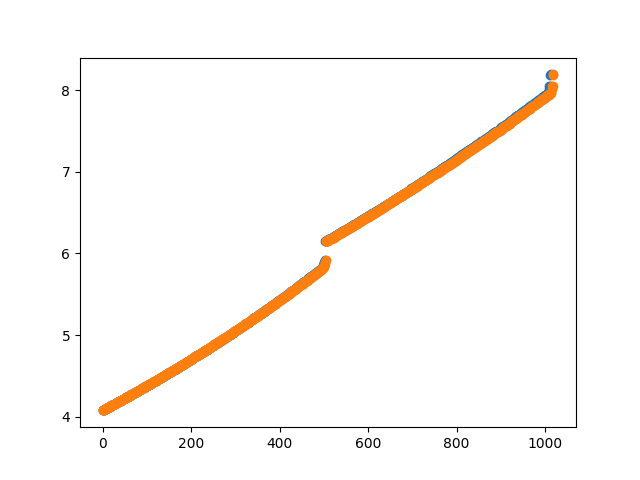

In [6]:
fig, ax = plt.subplots()
ax.plot(durham, 'o ')
ax.plot(sron_sort_corr, 'o ')


In [8]:
durham_mapped_sort = np.empty(len(sron))
durham_mapped_sort[:] = np.nan
for f0 in durham:
    id = np.nanargmin(np.abs(sron_sort_corr - f0))
    durham_mapped_sort[id] = f0
durham_mapped = durham_mapped_sort[invargs]

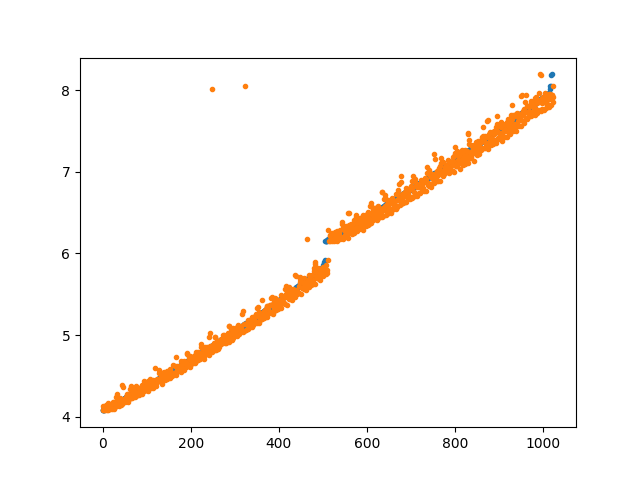

In [9]:
fig, ax = plt.subplots()
ax.plot(sron_sort_corr, '. ')
ax.plot(durham_mapped, '. ')

In [10]:
scatter = (durham_mapped - sron)/sron

3.5446049438855806e-05


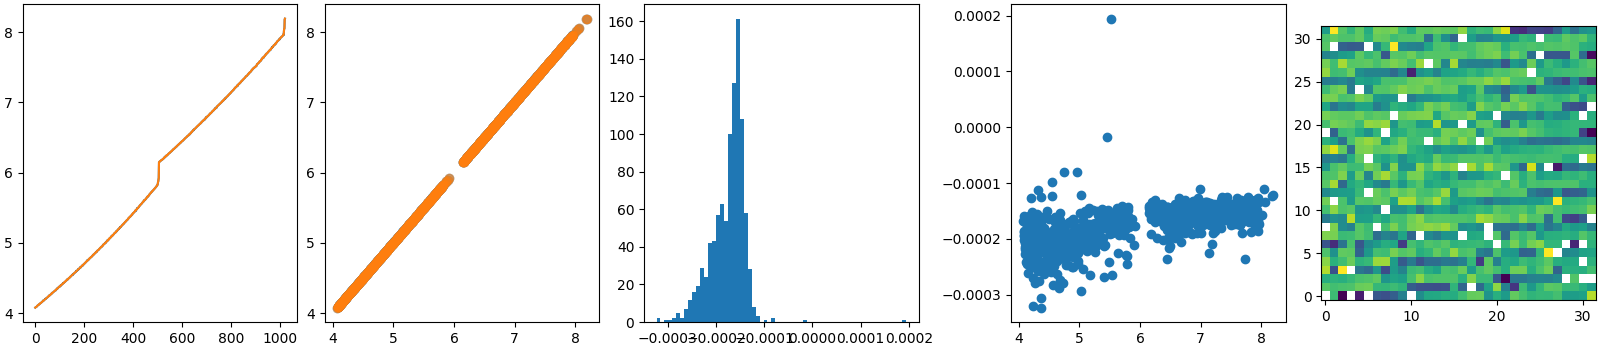

In [15]:
fig, axes = plt.subplot_mosaic('edabc', figsize=(16, 3.5), constrained_layout=True)
ax = axes['e']
ax.plot(durham_mapped_sort)
ax.plot(sron_sort)
ax = axes['d']
ax.scatter(sron, sron, alpha=.5)
ax.scatter(sron, durham_mapped, alpha=.5)
ax = axes['a']
_ = ax.hist(scatter, bins='auto')
print(np.nanstd(scatter[np.abs(scatter)<0.05]))
ax = axes['b']
ax.scatter(sron, scatter)
ax = axes['c']
ax.imshow(scatter[map], origin='lower', vmin=-.0003, vmax=-0.0001)

In [ ]:
trim = master['lensdesign']['f0']
lens = master['lensmeasured']['f0']
scatter_lens = (lens - trim)/trim
fig, axes = plt.subplot_mosaic('abc', figsize=(10, 3), constrained_layout=True)
ax = axes['a']
_ = ax.hist(scatter_lens, bins='auto')
ax = axes['b']
ax.scatter(trim, scatter_lens)
ax = axes['c']
ax.imshow(scatter_lens[map], origin='lower', vmin=-.013, vmax=-0.01)